In [26]:
# ============================================================
# 1️⃣ IMPORT
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity

from transformers import AutoTokenizer, AutoModel
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [17]:
# ============================================================
# 2️⃣ LOAD DATA
# ============================================================
df = pd.read_csv("AFNC_news_dataset_tf-2.csv")

#df = df.dropna(subset=["หัวข้อข่าว", "label"])
df = df.reset_index(drop=True)

In [18]:
# กำหนด mapping dictionary
label_map = {
    'ข่าวจริง': 'true',
    'ข่าวปลอม': 'fake',
}

In [19]:
# 1. ล้างเว้นวรรคผีหลอก และแปลงเป็น String
df['ประเภทข่าว'] = df['ประเภทข่าว'].astype(str).str.strip()
df['หมวดหมู่ของข่าว'] = df['หมวดหมู่ของข่าว'].astype(str).str.strip()

# 2. ปราบมาร: กรองแถวที่มีคำว่า 'nan', 'NaN', '', 'None' ทิ้งไปให้หมด
df = df[~df['ประเภทข่าว'].isin(['nan', 'NaN', '', 'None'])]
df = df[~df['หมวดหมู่ของข่าว'].isin(['nan', 'NaN', '', 'None'])]
df = df.dropna(subset=['หัวข้อข่าว', 'ประเภทข่าว', 'หมวดหมู่ของข่าว']).reset_index(drop=True)

# =======================================================
# 3. จัดการ Label (ข่าวจริง = 0, ข่าวปลอม = 1)
# =======================================================
# บังคับ Map ให้เป็น 0 กับ 1 เลยครับ โมเดล ML จะชอบแบบนี้ที่สุด
label2id = {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
id2label = {0: 'ข่าวจริง', 1: 'ข่าวปลอม'}

df['label_id'] = df['ประเภทข่าว'].map(label2id)

# ตัดแถวที่ Map ไม่ผ่านทิ้ง (เพื่อความชัวร์ 100%)
df = df.dropna(subset=['label_id']).reset_index(drop=True)
df['label_id'] = df['label_id'].astype(int)

print(f"✅ Label Classes: {label2id}")

✅ Label Classes: {'ข่าวจริง': 0, 'ข่าวปลอม': 1}


In [20]:
# ทำความสะอาด label ลบอิโมจิ และแมปค่า 
# Normalization Function

# Remove zero-width characters  
ZW = ''.join(['\u200B', '\u200C', '\u200D', '\uFEFF'])


def normalize_thai(s):
    if pd.isna(s):
        return None
    #non-breaking space
    s = str(s).replace('\u00A0', ' ').translate({ord(ch): None for ch in ZW})
    s = unicodedata.normalize('NFC', s)
    s = re.sub(r'\s+', ' ', s).strip()
    # collapse repeated diacritics/marks
    s = re.sub(r'([\u0E31\u0E34-\u0E3A\u0E47-\u0E4E])\1+', r'\1', s)
    return s

df['ประเภทข่าว'] = df['ประเภทข่าว'].apply(normalize_thai) #print
df['หมวดหมู่ของข่าว'] = df['หมวดหมู่ของข่าว'].apply(normalize_thai)


In [21]:
# โหลดโมเดลภาษาไทย + จัด device WangchanBERTa
model_WCB = "airesearch/wangchanberta-base-att-spm-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_WCB, use_fast=False)
#WangchanBERTa
lm_model = AutoModel.from_pretrained(model_WCB)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#ย้ายไปdevice    
lm_model = lm_model.to(device).eval()


In [22]:
# ดูตัวอย่าง content (raw text)
print("\nSample of content:")
print(df[['หัวข้อข่าว']].head(1))

# ถ้าต้องการสถิติ token length จาก BERT tokenizer
encoded_inputs = tokenizer(
    df['หัวข้อข่าว'].tolist(),
    padding=False,
    truncation=False,
    return_tensors=None
)

token_lengths = [len(tokens) for tokens in encoded_inputs['input_ids']]
print("\nToken statistics (from WangchanBERTa tokenizer):")
print(f"Average tokens in หัวข้อข่าว: {sum(token_lengths)/len(token_lengths):.2f}")

#--- TRUE NEWS SAMPLES ---
print("\nSample of true news content:")
print(df[df['label_binary'] == 'true'][['หัวข้อข่าว', 'label_binary']].head(2))

#--- FAKE NEWS SAMPLES ---
print("\nSample of fake news content:")
print(df[df['label_binary'] == 'fake'][['หัวข้อข่าว', 'label_binary']].head(2))



Sample of content:
                                          หัวข้อข่าว
0  กินหน่อไม้สดปริมาณมาก เสี่ยงรับพิษจากสารไซยาไน...

Token statistics (from WangchanBERTa tokenizer):
Average tokens in หัวข้อข่าว: 20.78

Sample of true news content:
                                           หัวข้อข่าว label_binary
21  รอรถเมล์นานสามารถร้องเรียนได้ที่เพจ ขสมก. พร้อ...         true
23  ดื่มชาที่ร้อนเกินไป เสี่ยงเป็นโรคมะเร็งหลอดอาห...         true

Sample of fake news content:
                                           หัวข้อข่าว label_binary
19   ดื่มนมเยอะ มีผลเสียต่อร่างกาย ทำให้เป็นหลากหล...         fake
20        ต้านโควิด-19 ได้ด้วย มันเทศญี่ปุ่นต้มน้ำขิง         fake


In [23]:
# ====================================================================
# SECTION 5: BERT EMBEDDING FUNCTION
# ====================================================================
@torch.no_grad()
def get_bert_embeddings_batch(
    texts, tokenizer, model, device,
    max_length=256, batch_size=32, use_mean_pool=True
):
    """สร้าง BERT embeddings แบบ batch → numpy array (N, hidden_size)"""
    model.eval()
    all_embeddings = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]
        batch_texts = [
            "" if (isinstance(t, float) and np.isnan(t)) else str(t)
            for t in batch_texts
        ]
        inputs = tokenizer(
            batch_texts,
            truncation=True, padding=True,
            max_length=max_length, return_tensors='pt'
        ).to(device)

        outputs     = model(**inputs)
        last_hidden = outputs.last_hidden_state   # (B, seq_len, hidden)

        if use_mean_pool:
            attn   = inputs['attention_mask'].unsqueeze(-1)
            summed = (last_hidden * attn).sum(dim=1)
            denom  = attn.sum(dim=1).clamp(min=1)
            emb    = (summed / denom).cpu().numpy()
        else:
            emb = last_hidden[:, 0, :].cpu().numpy()

        all_embeddings.append(emb)

    return np.vstack(all_embeddings)   # (N, hidden_size)

In [24]:
# =======================================================
# 3. จัดการ Label (ข่าวจริง = 0, ข่าวปลอม = 1)
# =======================================================
# บังคับ Map ให้เป็น 0 กับ 1 เลยครับ โมเดล ML จะชอบแบบนี้ที่สุด
label2id = {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
id2label = {0: 'ข่าวจริง', 1: 'ข่าวปลอม'}

df['label_id'] = df['ประเภทข่าว'].map(label2id)

# ตัดแถวที่ Map ไม่ผ่านทิ้ง (เพื่อความชัวร์ 100%)
df = df.dropna(subset=['label_id']).reset_index(drop=True)
df['label_id'] = df['label_id'].astype(int)

print(f"✅ Label Classes: {label2id}")

# =======================================================
# 4. จัดการ Category (หมวดหมู่ของข่าว)
# =======================================================
cats = sorted(df['หมวดหมู่ของข่าว'].unique())
cat2id = {c: i for i, c in enumerate(cats)}
id2cat = {i: c for c, i in cat2id.items()}

df['category_id'] = df['หมวดหมู่ของข่าว'].map(cat2id)
print(f"✅ Category Classes สร้างสำเร็จ ({len(cats)} หมวดหมู่)")

# =======================================================
# 5. ปรับสมดุลข้อมูล (Balancing Data) ให้เป็น 5,744 ข่าว
# =======================================================
# แยกกลุ่มข่าวจริงและข่าวปลอม
df_true = df[df['label_id'] == 0]
df_fake = df[df['label_id'] == 1]

print(f"\n📊 ก่อนปรับสมดุล: ข่าวจริง = {len(df_true)} ข่าว, ข่าวปลอม = {len(df_fake)} ข่าว")

# หาจำนวนของกลุ่มที่น้อยที่สุด (เพื่อให้ข้อมูล Balance กันเป๊ะๆ)
min_len = min(len(df_true), len(df_fake))

# สุ่มข้อมูลให้เท่ากับ min_len
df_true_sampled = df_true.sample(n=min_len, random_state=42)
df_fake_sampled = df_fake.sample(n=min_len, random_state=42)

# นำมาต่อกันแล้วสับไพ่ (Shuffle) ให้ข้อมูลกระจายตัว
df_balanced = pd.concat([df_true_sampled, df_fake_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"⚖️ หลังปรับสมดุล (รวมทั้งหมด {len(df_balanced)} ข่าว):")
print(df_balanced['ประเภทข่าว'].value_counts())
# =======================================================
# เตรียมตัวแปรหลัก (เหมือน pipeline แรก)
# =======================================================

df_balanced = df_balanced.reset_index(drop=True)

idx_balanced = df_balanced.index.values
N_balanced   = len(df_balanced)

y_balanced   = df_balanced['label_id'].values
y_cat_balanced = df_balanced['category_id'].values

print("✅ N_balanced:", N_balanced)
print("="*80)

✅ Label Classes: {'ข่าวจริง': 0, 'ข่าวปลอม': 1}
✅ Category Classes สร้างสำเร็จ (8 หมวดหมู่)

📊 ก่อนปรับสมดุล: ข่าวจริง = 2872 ข่าว, ข่าวปลอม = 8237 ข่าว
⚖️ หลังปรับสมดุล (รวมทั้งหมด 5744 ข่าว):
ประเภทข่าว
ข่าวจริง    2872
ข่าวปลอม    2872
Name: count, dtype: int64
✅ N_balanced: 5744



SECTION 7: CREATE BERT EMBEDDINGS


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


✅ x_balanced shape: (5744, 768)

SECTION 8: DATA VISUALIZATION


C:\Users\tt_pe\AppData\Local\Temp\ipykernel_24592\2723116522.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


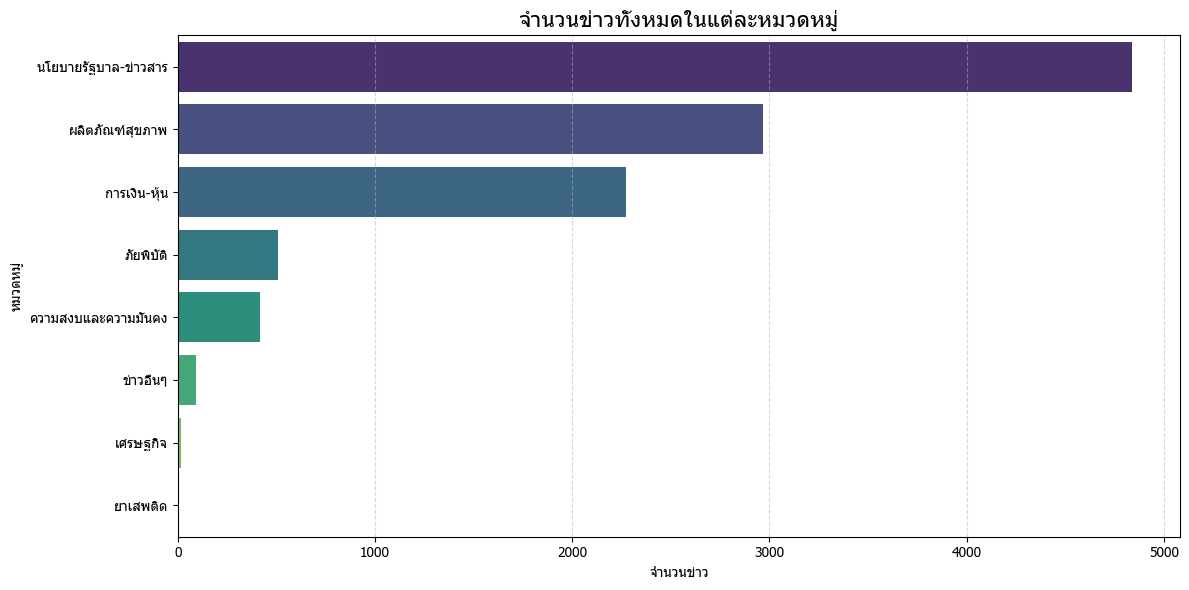

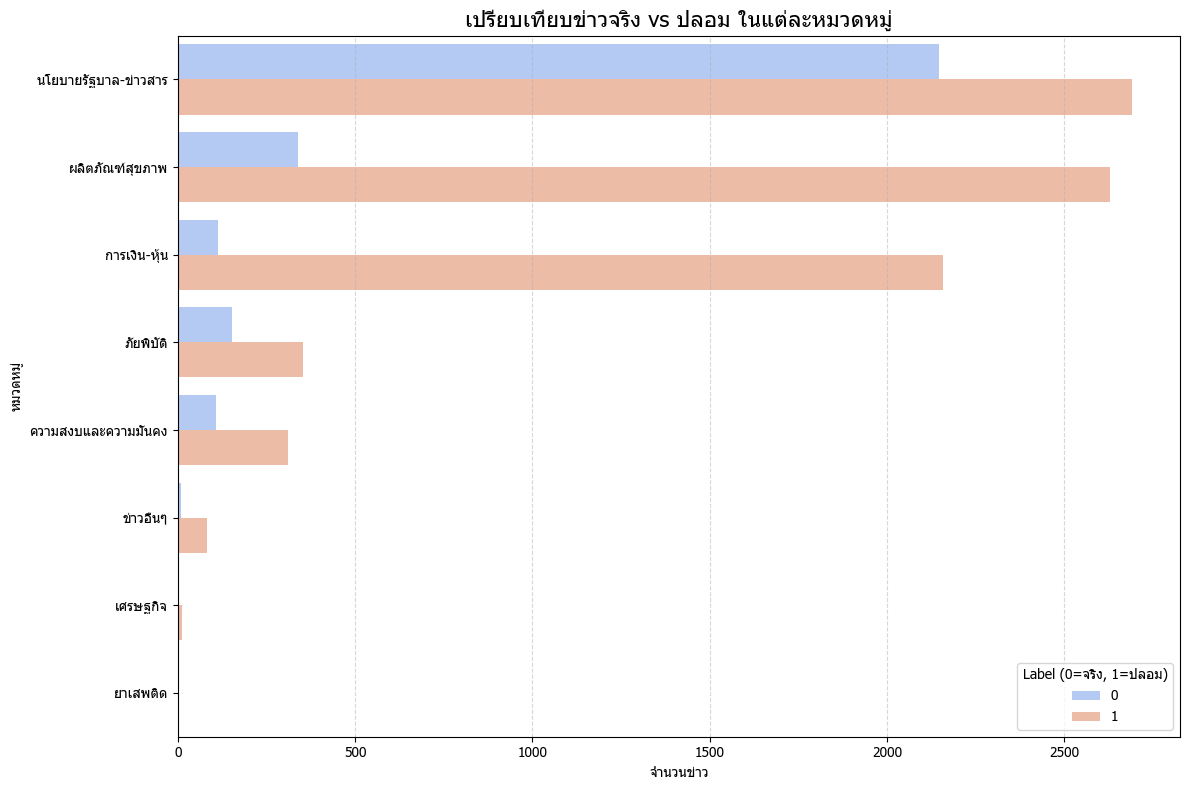

In [29]:
print("\nSECTION 7: CREATE BERT EMBEDDINGS")

texts_balanced = df_balanced['หัวข้อข่าว'].fillna("").astype(str).tolist()

content_emb = get_bert_embeddings_batch(
    texts_balanced,
    tokenizer=tokenizer,
    model=lm_model,
    device=device,
    max_length=256,
    batch_size=32,
    use_mean_pool=True
)

from sklearn.preprocessing import normalize
x_balanced = normalize(content_emb, axis=1, norm='l2')

print("✅ x_balanced shape:", x_balanced.shape)

# ====================================================================
# SECTION 8: DATA VISUALIZATION
# ====================================================================

print("\nSECTION 8: DATA VISUALIZATION")

import matplotlib.pyplot as plt
import seaborn as sns

col_category = 'หมวดหมู่ของข่าว'

try:
    plt.rcParams['font.family'] = 'Tahoma'
except:
    pass

# กราฟ 1: Overall Distribution
plt.figure(figsize=(12, 6))
sns.countplot(
    y=df[col_category],
    order=df[col_category].value_counts().index,
    palette='viridis'
)
plt.title('จำนวนข่าวทั้งหมดในแต่ละหมวดหมู่', fontsize=16)
plt.xlabel('จำนวนข่าว')
plt.ylabel('หมวดหมู่')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# กราฟ 2: Real vs Fake per Category
plt.figure(figsize=(12, 8))
sns.countplot(
    data=df,
    y=col_category,
    hue='label_id',
    order=df[col_category].value_counts().index,
    palette='coolwarm'
)
plt.title('เปรียบเทียบข่าวจริง vs ปลอม ในแต่ละหมวดหมู่', fontsize=16)
plt.xlabel('จำนวนข่าว')
plt.ylabel('หมวดหมู่')
plt.legend(title='Label (0=จริง, 1=ปลอม)', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [30]:
# ====================================================================
# SECTION 9: BUILD SPATIO-TEMPORAL GRAPH (FIXED VERSION)
# ====================================================================

print("\nSECTION 9: BUILD SPATIO-TEMPORAL GRAPH")

from sklearn.neighbors import NearestNeighbors
from torch_geometric.utils import coalesce

# --- 1. Spatial KNN Graph ---
k = 10
nbrs = NearestNeighbors(n_neighbors=k, metric='cosine')
nbrs.fit(x_balanced)

distances, indices = nbrs.kneighbors(x_balanced)

row = np.repeat(np.arange(N_balanced), k)
col = indices.flatten()

edge_index_spatial = np.vstack([row, col])
edge_weight_spatial = 1 - distances.flatten()

# --- 2. Temporal Weight (SAFE VERSION) ---

date_columns = ['parsed_date', 'วันที่เผยแพร่', 'date', 'publish_date']

date_col_found = None
for col in date_columns:
    if col in df_balanced.columns:
        date_col_found = col
        break

if date_col_found is not None:
    print(f"✅ Using date column: {date_col_found}")
    
    publish_dates = pd.to_datetime(df_balanced[date_col_found], errors='coerce')
    median_date = publish_dates.dropna().median()
    publish_dates = publish_dates.fillna(median_date)

    time_values = publish_dates.astype('int64') / 1e9 / 86400
    time_values = time_values.values

    time_diff = np.abs(time_values[row] - time_values[col])
    temporal_weight = np.exp(-0.05 * time_diff)

else:
    print("⚠ No date column found — using spatial graph only")
    temporal_weight = np.ones_like(edge_weight_spatial)

# --- 3. Fusion ---
edge_weight_final = edge_weight_spatial * temporal_weight

edge_index_st = torch.tensor(edge_index_spatial, dtype=torch.long)
edge_weight_st = torch.tensor(edge_weight_final, dtype=torch.float)

edge_index_st, edge_weight_st = coalesce(
    edge_index_st,
    edge_weight_st,
    num_nodes=N_balanced,
    reduce='mean'
)

print("✅ Nodes:", N_balanced)
print("✅ Edges:", edge_index_st.shape[1])


SECTION 9: BUILD SPATIO-TEMPORAL GRAPH
⚠ No date column found — using spatial graph only
✅ Nodes: 5744
✅ Edges: 57440



📊 Starting Data Analysis...

✅ 1. Creating Overall Distribution Graph...
หมวดหมู่ของข่าว
นโยบายรัฐบาล-ข่าวสาร    4838
ผลิตภัณฑ์สุขภาพ         2967
การเงิน-หุ้น            2271
ภัยพิบัติ                507
ความสงบและความมั่นคง     418
ข่าวอื่นๆ                 92
เศรษฐกิจ                  14
ยาเสพติด                   2
Name: count, dtype: int64


C:\Users\tt_pe\AppData\Local\Temp\ipykernel_24592\3876794720.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


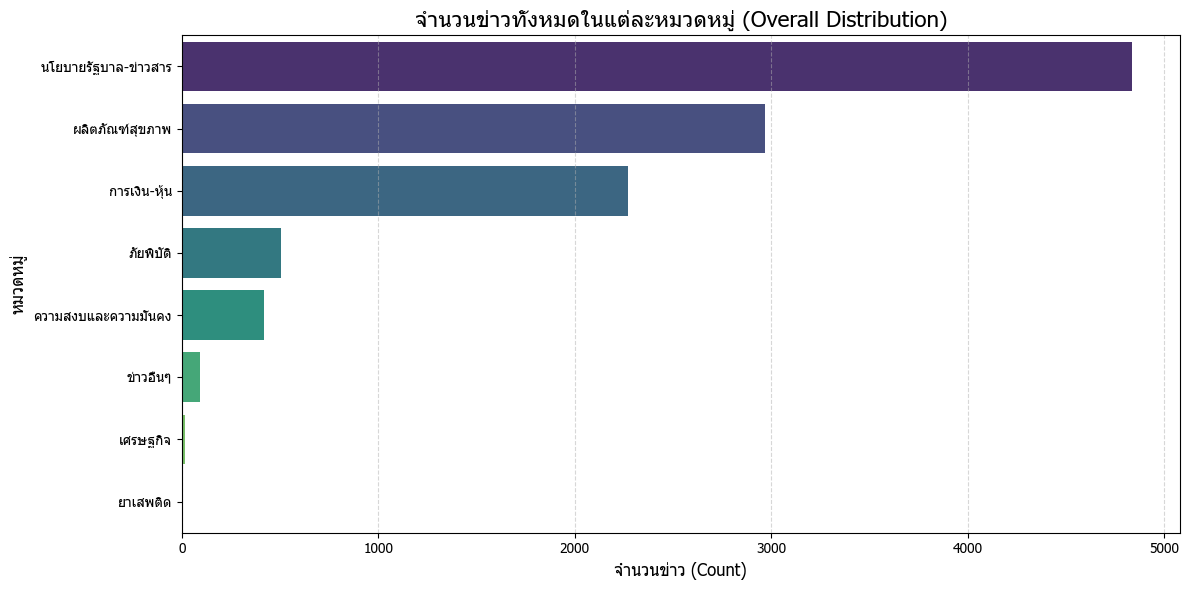


✅ 2. Creating Comparison Graph (Real vs Fake)...
label_binary          fake  true
หมวดหมู่ของข่าว                 
การเงิน-หุ้น          2158   111
ข่าวอื่นๆ               83     9
ความสงบและความมั่นคง   310    57
นโยบายรัฐบาล-ข่าวสาร  2692  2128
ผลิตภัณฑ์สุขภาพ       2629   335
ภัยพิบัติ              354   151
ยาเสพติด                 0     2
เศรษฐกิจ                11     3


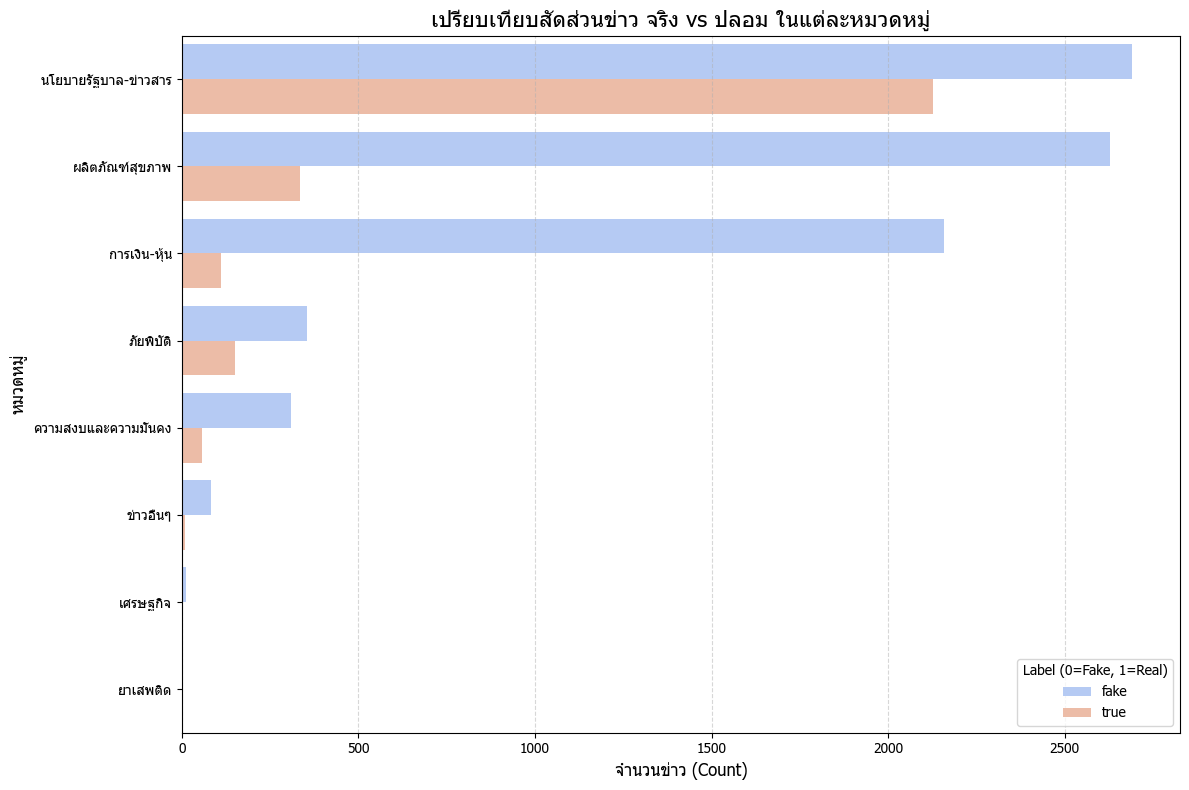


✅ Saved graphs: graph_category_total.png, graph_category_comparison.png


In [32]:
# ====================================================================
# 📊 DATA ANALYSIS & VISUALIZATION (ฉบับครบ 2 กราฟ)
# ====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n📊 Starting Data Analysis...")

# --- 1. ตั้งค่าตัวแปรชื่อคอลัมน์ (ตรวจสอบให้ตรงกับไฟล์ CSV) ---
col_category = 'หมวดหมู่ของข่าว'   # ชื่อคอลัมน์หมวดหมู่
col_label = 'label_binary'       # ชื่อคอลัมน์เฉลย (0, 1)

# --- 2. ตั้งค่าฟอนต์ภาษาไทย ---
try:
    plt.rcParams['font.family'] = 'Tahoma' # Windows ใช้ Tahoma
except:
    pass

if col_category in df.columns:
    
    # ============================================================
    # 🟢 กราฟที่ 1: ดูภาพรวม (Overall Distribution) - อันเดิมที่คุณต้องการเก็บไว้
    # ============================================================
    print(f"\n✅ 1. Creating Overall Distribution Graph...")
    
    # นับจำนวนและปริ้นท์
    category_counts = df[col_category].value_counts()
    print(category_counts)
    
    plt.figure(figsize=(12, 6)) # สร้างหน้ากระดาษใหม่
    sns.countplot(
        y=df[col_category], 
        order=df[col_category].value_counts().index,
        palette='viridis' # สีโทนเขียว-ม่วง (ดูภาพรวม)
    )
    plt.title('จำนวนข่าวทั้งหมดในแต่ละหมวดหมู่ (Overall Distribution)', fontsize=16)
    plt.xlabel('จำนวนข่าว (Count)', fontsize=12)
    plt.ylabel('หมวดหมู่', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    #plt.savefig('graph_category_total.png') # เซฟรูปที่ 1
    plt.show() # โชว์รูปที่ 1


    # ============================================================
    # 🔴 กราฟที่ 2: เปรียบเทียบ จริง vs ปลอม (Real vs Fake Comparison)
    # ============================================================
    if col_label in df.columns:
        print(f"\n✅ 2. Creating Comparison Graph (Real vs Fake)...")
        
        # ปริ้นท์ตารางตัวเลขเทียบดู
        cross_tab = pd.crosstab(df[col_category], df[col_label])
        print(cross_tab)
        
        plt.figure(figsize=(12, 8)) # สร้างหน้ากระดาษใหม่
        sns.countplot(
            data=df,
            y=col_category,
            hue=col_label,       # 🔥 แยกสีตามจริง/ปลอม
            order=df[col_category].value_counts().index, # เรียงตามกราฟแรก
            palette='coolwarm'   # สีโทนร้อน/เย็น (แยกความต่าง)
        )
        
        plt.title('เปรียบเทียบสัดส่วนข่าว จริง vs ปลอม ในแต่ละหมวดหมู่', fontsize=16)
        plt.xlabel('จำนวนข่าว (Count)', fontsize=12)
        plt.ylabel('หมวดหมู่', fontsize=12)
        plt.legend(title='Label (0=Fake, 1=Real)', loc='lower right')
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        #plt.savefig('graph_category_comparison.png') # เซฟรูปที่ 2
        plt.show() # โชว์รูปที่ 2
        
    print("\n✅ Saved graphs: graph_category_total.png, graph_category_comparison.png")

else:
    print(f"⚠️ ไม่พบคอลัมน์ '{col_category}' ข้ามขั้นตอนสร้างกราฟ")

print("====================================================================")

In [33]:
# ====================================================================
# GCN Model Definition 
# ====================================================================
class GCNNet(nn.Module):
    def __init__(self, num_node_features, num_classes, hidden_channels=256, dropout_rate=0.4):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)
        self.dropout_rate = dropout_rate

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # ถ้ามี edge weights ให้ใช้
        edge_weight = getattr(data, 'edge_attr', None)
        
        # Layer 1
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        # Layer 2
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        
        return x  # logits (ส่งไปเข้า CrossEntropyLoss)


# ====================================================================
# Evaluation Function
# ====================================================================
def evaluate_masked(logits, mask, data):
    # เปลี่ยน logits เป็น class prediction (0 หรือ 1)
    y_pred = logits[mask].argmax(dim=1).cpu().numpy()
    y_true = data.y[mask].cpu().numpy()
    
    # คำนวณ Metrics พื้นฐาน
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    # (Optional) ถ้าอยากเห็น Report ละเอียดให้ print ออกมาดูได้
    # print(classification_report(y_true, y_pred, target_names=['News Real', 'News Fake'], digits=4))
    
    return acc, f1m

In [34]:
# ====================================================================
# SECTION 10: TRAIN/VAL/TEST SPLIT & DATA OBJECT
# ====================================================================
print("\nSECTION 10: TRAIN/VAL/TEST SPLIT")

x_tensor_st = torch.tensor(x_balanced, dtype=torch.float)
y_tensor_st = torch.tensor(y_balanced, dtype=torch.long)
idx_all     = np.arange(N_balanced)

idx_train, idx_temp = train_test_split(
    idx_all, test_size=0.30, stratify=y_balanced, random_state=42
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=y_balanced[idx_temp], random_state=42
)

train_mask = torch.zeros(N_balanced, dtype=torch.bool); train_mask[idx_train] = True
val_mask   = torch.zeros(N_balanced, dtype=torch.bool); val_mask[idx_val]     = True
test_mask  = torch.zeros(N_balanced, dtype=torch.bool); test_mask[idx_test]   = True

# ✅ ใช้ data_st (Spatio-Temporal) เป็นหลักตลอดทั้งโค้ด
data_st = Data(
    x          = x_tensor_st,
    y          = y_tensor_st,
    edge_index = edge_index_st,
    edge_attr  = edge_weight_st.float(),
    train_mask = train_mask,
    val_mask   = val_mask,
    test_mask  = test_mask,
)
data_st = data_st.to(device)

print(f"✅ data_st → Nodes: {data_st.num_nodes}, Edges: {data_st.num_edges}")
print(f"   Train: {train_mask.sum().item()} | Val: {val_mask.sum().item()} | Test: {test_mask.sum().item()}")



SECTION 10: TRAIN/VAL/TEST SPLIT
✅ data_st → Nodes: 5744, Edges: 57440
   Train: 4020 | Val: 862 | Test: 862



SECTION 12: TRAIN GCN (Spatio-Temporal Graph)
   Epoch 020: Loss 0.4620 | Train 0.8047 | Val 0.7796
   Epoch 040: Loss 0.3780 | Train 0.8286 | Val 0.8283
   Epoch 060: Loss 0.3458 | Train 0.8418 | Val 0.8422
   Epoch 080: Loss 0.3289 | Train 0.8537 | Val 0.8445
   Epoch 100: Loss 0.3178 | Train 0.8597 | Val 0.8480
   Epoch 120: Loss 0.3072 | Train 0.8672 | Val 0.8503
   Epoch 140: Loss 0.3003 | Train 0.8721 | Val 0.8550
   Epoch 160: Loss 0.2955 | Train 0.8739 | Val 0.8573
   Epoch 180: Loss 0.2910 | Train 0.8759 | Val 0.8573
   Epoch 200: Loss 0.2867 | Train 0.8801 | Val 0.8573

✅ Training Complete! Best Val Acc: 0.8596


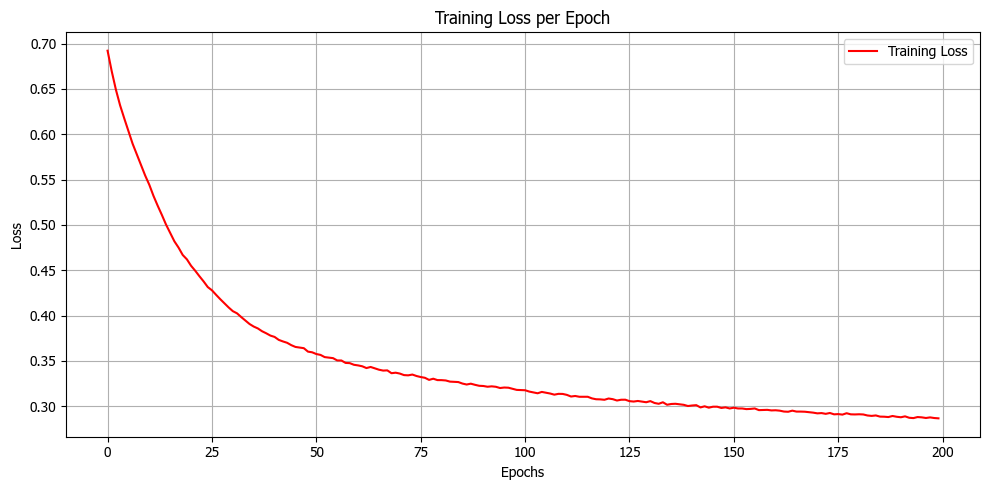

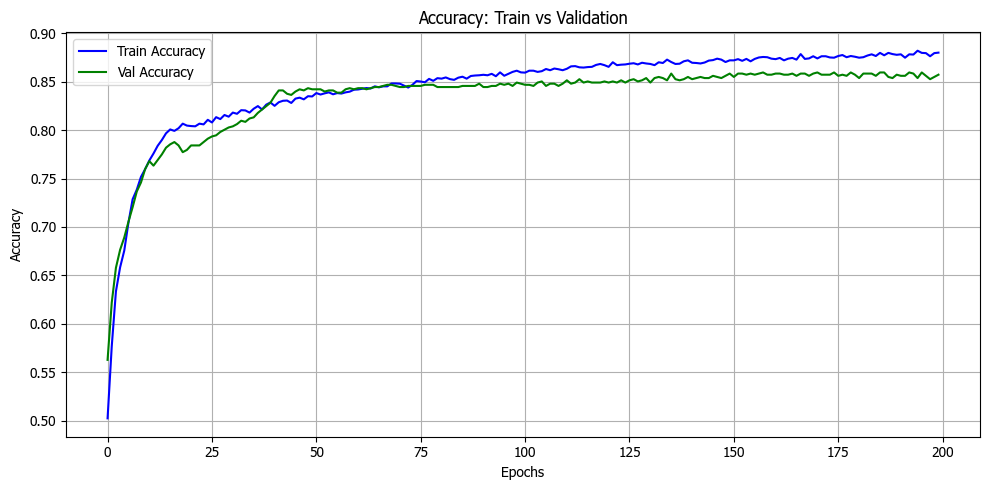

In [35]:
# ====================================================================
# SECTION 11: GCN MODEL DEFINITION
# ====================================================================
class GCNNet(nn.Module):
    def __init__(self, num_node_features, num_classes,
                 hidden_channels=256, dropout_rate=0.4):
        super().__init__()
        self.conv1        = GCNConv(num_node_features, hidden_channels)
        self.conv2        = GCNConv(hidden_channels, num_classes)
        self.dropout_rate = dropout_rate

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_weight   = getattr(data, 'edge_attr', None)

        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return x

# ====================================================================
# SECTION 12: TRAIN GCN
# ====================================================================
print("\nSECTION 12: TRAIN GCN (Spatio-Temporal Graph)")

model_gnn = GCNNet(data_st.num_features, 2).to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, 201):
    # --- Train ---
    model_gnn.train()
    optimizer.zero_grad()
    out  = model_gnn(data_st)                                    # ✅ data_st
    loss = criterion(out[data_st.train_mask], data_st.y[data_st.train_mask])
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        pred_train  = out[data_st.train_mask].argmax(dim=1)
        train_acc   = (pred_train == data_st.y[data_st.train_mask]).float().mean().item()
        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)

    # --- Validate ---
    model_gnn.eval()
    with torch.no_grad():
        pred    = model_gnn(data_st).argmax(dim=1)               # ✅ data_st
        val_acc = (pred[data_st.val_mask] == data_st.y[data_st.val_mask]).float().mean().item()
        history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc

    if epoch % 20 == 0:
        print(f"   Epoch {epoch:03d}: Loss {loss:.4f} | Train {train_acc:.4f} | Val {val_acc:.4f}")

print(f"\n✅ Training Complete! Best Val Acc: {best_val_acc:.4f}")

# --- Plot Training History ---
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Training Loss', color='red')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(history['val_acc'],   label='Val Accuracy',   color='green')
plt.title('Accuracy: Train vs Validation')
plt.xlabel('Epochs'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [36]:
# ====================================================================
# SECTION 13: PREDICT FUNCTION
# ====================================================================
def predict_news(
    content, topn=10,
    x_np=None, label2id=None, id2label=None,
    y_cat_np=None, id2cat=None,
    device=None, nbrs=None, model_gnn=None, embed_fn=None
):
    if embed_fn is None:
        raise ValueError("Missing 'embed_fn'.")

    # 1. Embedding
    emb_batch   = embed_fn([content])
    content_emb = emb_batch[0]
    emb         = normalize(content_emb.reshape(1, -1), axis=1, norm='l2')[0]

    # 2. KNN Search
    dists, idxs = nbrs.kneighbors(emb.reshape(1, -1), n_neighbors=topn)
    idxs        = idxs[0]

    # 3. Category Prediction (Majority Vote)
    pred_category = "ไม่ระบุ"
    neighbor_cats = []
    if y_cat_np is not None and id2cat is not None:
        try:
            neighbor_cats = [id2cat[cid] for cid in y_cat_np[idxs]]
            most_common   = Counter(neighbor_cats).most_common(1)
            if most_common:
                pred_category = most_common[0][0]
        except Exception as e:
            print(f"⚠️ Category Warning: {e}")

    # 4. Build Star Graph for GCN
    X_new     = np.vstack([emb, x_np[idxs]])
    center    = 0
    neighbors = np.arange(1, topn + 1)

    edge_index_new = np.concatenate([
        np.stack([np.full(topn, center), neighbors]),
        np.stack([neighbors, np.full(topn, center)])
    ], axis=1)
    edge_weight_new = np.concatenate([1 - dists[0], 1 - dists[0]])

    data_new = Data(
        x          = torch.tensor(X_new, dtype=torch.float, device=device),
        edge_index = torch.tensor(edge_index_new, dtype=torch.long, device=device),
        edge_attr  = torch.tensor(edge_weight_new, dtype=torch.float, device=device),
    )

    # 5. Predict
    model_gnn.eval()
    with torch.no_grad():
        logits   = model_gnn(data_new)
        probas   = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_id  = int(np.argmax(probas))

    return {
        'label':         id2label[pred_id],
        'probability':   float(probas[pred_id]),
        'proba_all':     probas.tolist(),
        'category':      pred_category,
        'neighbor_cats': neighbor_cats,
        'pred_id':       pred_id
    }


In [38]:
# ====================================================================
# 5. Train Model & Plotting (Spatio-Temporal Version)
# ====================================================================

print("\n🔄 5. Training GCN...")

model_gnn = GCNNet(data_st.num_features, 2).to(device)
optimizer = torch.optim.Adam(model_gnn.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

history = {
    'train_loss': [],
    'train_acc': [],
    'val_acc': []
}

best_val_acc = 0

for epoch in range(1, 201):
    model_gnn.train()
    optimizer.zero_grad()

    out = model_gnn(data_st)

    loss = criterion(out[data_st.train_mask], data_st.y[data_st.train_mask])
    loss.backward()
    optimizer.step()

    # --- Training Accuracy ---
    with torch.no_grad():
        pred_train = out[data_st.train_mask].argmax(dim=1)
        train_correct = (pred_train == data_st.y[data_st.train_mask]).sum()
        train_acc = int(train_correct) / int(data_st.train_mask.sum())

        history['train_loss'].append(loss.item())
        history['train_acc'].append(train_acc)

    # --- Validation ---
    model_gnn.eval()
    with torch.no_grad():
        pred = model_gnn(data_st).argmax(dim=1)
        val_correct = (pred[data_st.val_mask] == data_st.y[data_st.val_mask]).sum()
        val_acc = int(val_correct) / int(data_st.val_mask.sum())

        history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss {loss:.4f} | Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f}")

print(f"\n✅ Training Complete! Best Val Acc: {best_val_acc:.4f}")


🔄 5. Training GCN...
Epoch 020 | Loss 0.4555 | Train Acc 0.8060 | Val Acc 0.7865
Epoch 040 | Loss 0.3753 | Train Acc 0.8289 | Val Acc 0.8329
Epoch 060 | Loss 0.3462 | Train Acc 0.8425 | Val Acc 0.8445
Epoch 080 | Loss 0.3281 | Train Acc 0.8505 | Val Acc 0.8469
Epoch 100 | Loss 0.3153 | Train Acc 0.8637 | Val Acc 0.8480
Epoch 120 | Loss 0.3068 | Train Acc 0.8647 | Val Acc 0.8527
Epoch 140 | Loss 0.2998 | Train Acc 0.8739 | Val Acc 0.8561
Epoch 160 | Loss 0.2941 | Train Acc 0.8741 | Val Acc 0.8573
Epoch 180 | Loss 0.2894 | Train Acc 0.8731 | Val Acc 0.8608
Epoch 200 | Loss 0.2849 | Train Acc 0.8799 | Val Acc 0.8538

✅ Training Complete! Best Val Acc: 0.8608


In [ ]:
# # ====================================================================
# # 6. Save Artifacts (ใช้ข้อมูล x_balanced ที่เตรียมไว้ตอนแรก)
# # ====================================================================
# artifacts = {
#     'x_np': x_balanced,         # ✅ ใช้ข้อมูลเรียงวันที่
#     'y_cat_np': y_cat_balanced if 'y_cat_balanced' in globals() else None, 
#     'y_label_np': y_balanced,
#     'id2cat': id2cat if 'id2cat' in globals() else None,
#     'id2label': {0: 'ข่าวจริง', 1: 'ข่าวปลอม'},
#     'k': 10,
#     'model': model_gnn,
# }
# with open('artifacts.pkl', 'wb') as f:
#     pickle.dump(artifacts, f)
# print("✅ Saved 'artifacts.pkl' (Date-Balanced Version)")

In [39]:
# ====================================================================
# PART 1 — Evaluate GCN on Test Set
# ====================================================================
print("\n" + "="*80)
print("PART 1: GCN EVALUATION ON TEST SET")
print("="*80)

model_gnn.eval()
with torch.no_grad():
    final_out_gcn = model_gnn(data_st)                           # ✅ data_st

    # ✅ ดึงจาก data_st.test_mask
    y_true_gcn = data_st.y[data_st.test_mask].cpu().numpy()
    y_pred_gcn = final_out_gcn[data_st.test_mask].argmax(dim=1).cpu().numpy()

acc       = accuracy_score(y_true_gcn, y_pred_gcn)
precision = precision_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)
recall    = recall_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)
f1        = f1_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)

results_gcn = {
    "Accuracy":            float(acc),
    "Precision_weighted":  float(precision),
    "Recall_weighted":     float(recall),
    "F1_weighted":         float(f1),
}

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_true_gcn, y_pred_gcn, digits=4))



PART 1: GCN EVALUATION ON TEST SET
Accuracy : 0.8689
Precision: 0.8691
Recall   : 0.8689
F1-score : 0.8689

Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.8786    0.8561    0.8672       431
           1     0.8597    0.8817    0.8706       431

    accuracy                         0.8689       862
   macro avg     0.8691    0.8689    0.8689       862
weighted avg     0.8691    0.8689    0.8689       862



In [40]:
# ====================================================================
# PART 2 — Predict New News Samples
# ====================================================================
print("\n" + "="*80)
print("PART 2: PREDICT NEW NEWS SAMPLES")
print("="*80)

test_news_data = [
    # ข่าวจริง (Label 0)
    {"content": "ททท. เปิดตัว 'ลิซ่า' เป็นตัวแทนการท่องเที่ยวไทย Amazing Thailand Ambassador", "label_true": 0},
    {"content": "สั่งสำรวจ-เก็บวัตถุโบราณ เร่งบูรณะ 'พระธาตุโนนตาล' หลังพังถล่มจากฝนตกหนัก",  "label_true": 0},
    {"content": "บขส. เปิดให้บริการเดินรถโดยสาร เส้นทาง ขอนแก่น – นครหลวงเวียงจันทน์",          "label_true": 0},
    {"content": "อุทยานฯ เขาพนมเบญจา ชวนนักท่องเที่ยว ตามรอยจูราสสิค เวิลด์",                    "label_true": 0},
    {"content": "พบอิฐโบราณชิ้นสำคัญ หลักฐานทางประวัติศาสตร์ที่เก่าแก่ของเชียงราย",              "label_true": 0},
    {"content": "ปิดเทอม สวนสัตว์เปิดเขาเขียว เผยโฉม 'ลูกสมเสร็จตัวล่าสุด'",                    "label_true": 0},
    {"content": "อาการเจ็บหน้าอก สัญญาณอันตรายที่ไม่ควรมองข้าม",                                "label_true": 0},
    {"content": "กกล.บูรพา จับกุมแรงงานกัมพูชา 11 คน ลักลอบข้ามชายแดนสระแก้ว",                  "label_true": 0},
    {"content": "ททท.คาด 'เทศกาลกินผักภูเก็ต 2568' รายได้ทะลุ 22,000 ล้านบาท",                   "label_true": 0},
    {"content": "'ข้าวต้ม' ฟื้นตัวดี ถีบตัวลุกได้ ทีมแพทย์ช่วยกายภาพต่อเนื่อง",                 "label_true": 0},
    # ข่าวปลอม (Label 1)
    {"content": "ด่วน! สะพานกรุงเทพถล่ม มีผู้เสียชีวิต 36 ราย",                                   "label_true": 1},
    {"content": "กระทรวงยุติธรรม เปิดให้ลงทะเบียนรับเงิน 15,000 บาท",                             "label_true": 1},
]

k           = 10
current_nbrs = NearestNeighbors(n_neighbors=k, metric='cosine').fit(x_balanced)

# ✅ ใช้ชื่อต่างออกไปเพื่อไม่ทับกับตัวแปรอื่น
y_true_part2 = []
y_pred_part2 = []

my_embed_fn = lambda texts: get_bert_embeddings_batch(
    texts, tokenizer=tokenizer, model=lm_model, device=device
)

print("-" * 80)
for i, news in enumerate(test_news_data):
    try:
        result  = predict_news(
            content=news['content'],
            x_np=x_balanced, nbrs=current_nbrs,
            label2id=label2id, id2label=id2label,
            y_cat_np=y_cat_balanced, id2cat=id2cat,
            device=device, topn=k,
            model_gnn=model_gnn, embed_fn=my_embed_fn
        )
        pred_id = result['pred_id']
        y_true_part2.append(news["label_true"])
        y_pred_part2.append(pred_id)

        status = "✅" if pred_id == news["label_true"] else "❌"
        print(f"[{status}] {news['content'][:55]}...")
        print(f"    TRUE: {id2label[news['label_true']]} | PRED: {result['label']} | Prob: {result['probability']:.3f}")
        print(f"    หมวดหมู่: {result['category']}")
        print("-" * 50)

    except Exception as e:
        print(f"Error sample {i}: {e}")
        # Summary Report (Part 2)
if y_pred_part2:
    cm   = confusion_matrix(y_true_part2, y_pred_part2)
    acc  = accuracy_score(y_true_part2, y_pred_part2)
    prec = precision_score(y_true_part2, y_pred_part2, zero_division=0)
    rec  = recall_score(y_true_part2, y_pred_part2, zero_division=0)
    f1_s = f1_score(y_true_part2, y_pred_part2, zero_division=0)

    print("\n" + "="*60)
    print("PART 2 SUMMARY")
    print("="*60)
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1_s:.4f}")
    print(classification_report(
        y_true_part2, y_pred_part2,
        target_names=[id2label[0], id2label[1]], zero_division=0
    ))


PART 2: PREDICT NEW NEWS SAMPLES
--------------------------------------------------------------------------------


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


[❌] ททท. เปิดตัว 'ลิซ่า' เป็นตัวแทนการท่องเที่ยวไทย Amazing...
    TRUE: ข่าวจริง | PRED: ข่าวปลอม | Prob: 0.555
    หมวดหมู่: นโยบายรัฐบาล-ข่าวสาร
--------------------------------------------------
[✅] สั่งสำรวจ-เก็บวัตถุโบราณ เร่งบูรณะ 'พระธาตุโนนตาล' หลัง...
    TRUE: ข่าวจริง | PRED: ข่าวจริง | Prob: 0.996
    หมวดหมู่: นโยบายรัฐบาล-ข่าวสาร
--------------------------------------------------


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


[✅] บขส. เปิดให้บริการเดินรถโดยสาร เส้นทาง ขอนแก่น – นครหลว...
    TRUE: ข่าวจริง | PRED: ข่าวจริง | Prob: 0.919
    หมวดหมู่: นโยบายรัฐบาล-ข่าวสาร
--------------------------------------------------
[✅] อุทยานฯ เขาพนมเบญจา ชวนนักท่องเที่ยว ตามรอยจูราสสิค เวิ...
    TRUE: ข่าวจริง | PRED: ข่าวจริง | Prob: 1.000
    หมวดหมู่: นโยบายรัฐบาล-ข่าวสาร
--------------------------------------------------
[❌] พบอิฐโบราณชิ้นสำคัญ หลักฐานทางประวัติศาสตร์ที่เก่าแก่ขอ...
    TRUE: ข่าวจริง | PRED: ข่าวปลอม | Prob: 0.914
    หมวดหมู่: ผลิตภัณฑ์สุขภาพ
--------------------------------------------------


...

c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


[✅] กกล.บูรพา จับกุมแรงงานกัมพูชา 11 คน ลักลอบข้ามชายแดนสระ...
    TRUE: ข่าวจริง | PRED: ข่าวจริง | Prob: 0.766
    หมวดหมู่: นโยบายรัฐบาล-ข่าวสาร
--------------------------------------------------
[✅] ททท.คาด 'เทศกาลกินผักภูเก็ต 2568' รายได้ทะลุ 22,000 ล้า...
    TRUE: ข่าวจริง | PRED: ข่าวจริง | Prob: 0.972
    หมวดหมู่: นโยบายรัฐบาล-ข่าวสาร
--------------------------------------------------
[❌] 'ข้าวต้ม' ฟื้นตัวดี ถีบตัวลุกได้ ทีมแพทย์ช่วยกายภาพต่อเ...
    TRUE: ข่าวจริง | PRED: ข่าวปลอม | Prob: 0.863
    หมวดหมู่: ผลิตภัณฑ์สุขภาพ
--------------------------------------------------


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


[✅] ด่วน! สะพานกรุงเทพถล่ม มีผู้เสียชีวิต 36 ราย...
    TRUE: ข่าวปลอม | PRED: ข่าวปลอม | Prob: 0.730
    หมวดหมู่: ผลิตภัณฑ์สุขภาพ
--------------------------------------------------
[✅] กระทรวงยุติธรรม เปิดให้ลงทะเบียนรับเงิน 15,000 บาท...
    TRUE: ข่าวปลอม | PRED: ข่าวปลอม | Prob: 0.701
    หมวดหมู่: นโยบายรัฐบาล-ข่าวสาร
--------------------------------------------------

PART 2 SUMMARY
Confusion Matrix:
[[6 4]
 [0 2]]
Accuracy : 0.6667
Precision: 0.3333
Recall   : 1.0000
F1-Score : 0.5000
              precision    recall  f1-score   support

    ข่าวจริง       1.00      0.60      0.75        10
    ข่าวปลอม       0.33      1.00      0.50         2

    accuracy                           0.67        12
   macro avg       0.67      0.80      0.62        12
weighted avg       0.89      0.67      0.71        12



c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


In [41]:
# warnings.filterwarnings("ignore", message=".*encoder_attention_mask.*")
# warnings.filterwarnings("ignore", message=".*CamembertSdpaSelfAttention.*")
# # ====================================================================
# # PART 1 — Evaluate GCN on Test set
# # ====================================================================
# model_gnn.eval()
# with torch.no_grad():
#     final_out_gcn = model_gnn(data_st)   # ✅ แก้: data → data_st

#     y_true_gcn = data_st.y[data_st.test_mask].cpu().numpy()   # ✅ แก้
#     y_pred_gcn = final_out_gcn[data_st.test_mask].argmax(dim=1).cpu().numpy()  # ✅ แก้

# acc       = accuracy_score(y_true_gcn, y_pred_gcn)
# precision = precision_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)
# recall    = recall_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)
# f1        = f1_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)

# results_gcn = {
#     "Accuracy": float(acc),
#     "Precision_weighted": float(precision),
#     "Recall_weighted": float(recall),
#     "F1_weighted": float(f1),
# }

# print("-" * 60)
# print("GCN Test Evaluation (Spatio-Temporal Graph)")  # ✅ แก้ข้อความ
# print("-" * 60)
# print(f"Accuracy : {acc:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall   : {recall:.4f}")
# print(f"F1-score : {f1:.4f}")
# print("-" * 60)
# print("\nDetailed Classification Report:")
# print(classification_report(y_true_gcn, y_pred_gcn, digits=4))

In [42]:
# # 📌  สร้างชุดข้อมูลทดสอบใหม่ (Test Set) 20 ข่าว
# # 'label_true': 0 = ข่าวจริง, 1 = ข่าวปลอม (ตาม label2id: {'ข่าวจริง': 0, 'ข่าวปลอม': 1})
# test_news_data = [
#     # --- ข่าวจริง 10 ตัวอย่าง (Label 0) ---
#     {"content": "ททท. เปิดตัว “ลิซ่า” เป็นตัวแทนการท่องเที่ยวไทย Amazing Thailand Ambassador","label_true": 0},
#     {"content": "สั่งสำรวจ-เก็บวัตถุโบราณ เร่งบูรณะ 'พระธาตุโนนตาล' หลังพังถล่มจากฝนตกหนัก", "label_true": 0},
#     {"content": "บขส. เปิดให้บริการเดินรถโดยสาร เส้นทาง ขอนแก่น – นครหลวงเวียงจันทน์", "label_true": 0},
#     {"content": "อุทยานฯ เขาพนมเบญจา ชวนนักท่องเที่ยว ตามรอยจูราสสิค เวิลด์ กำเนิดชีวิตใหม่ น้ำตกห้วยโต้", "label_true": 0},
#     {"content": "พบอิฐโบราณชิ้นสำคัญ หลักฐานทางประวัติศาสตร์ที่เก่าแก่ของเชียงราย", "label_true": 0},
#     {"content": "ปิดเทอม สวนสัตว์เปิดเขาเขียว เผยโฉม 'ลูกสมเสร็จตัวล่าสุด' เด็กเที่ยวฟรี 23 ตุลาคมนี้", "label_true": 0},
#     {"content": "อาการเจ็บหน้าอก สัญญาณอันตรายที่ไม่ควรมองข้าม","label_true": 0},
#     {"content": "กกล.บูรพา จับกุมแรงงานกัมพูชา 11 คน ลักลอบข้ามชายแดนสระแก้ว","label_true": 0},
#     {"content": "ททท.คาด 'เทศกาลกินผักภูเก็ต 2568' คึกคัก รายได้ทะลุ 22,000 ล้านบาท หนุนเศรษฐกิจสะพัด", "label_true": 0},
#     {"content": "“ข้าวต้ม” ฟื้นตัวดี ถีบตัวลุกได้ ทีมแพทย์ช่วยกายภาพต่อเนื่อง", "label_true": 0},
    
#     # --- ข่าวปลอม 10 ตัวอย่าง (Label 1) ---
#     {"content": "ด่วน! สะพานกรุงเทพถล่ม มีผู้เสียชีวิต 36 ราย", "label_true": 1},
#     {"content": "กระทรวงยุติธรรม ร่วมกับ ตำรวจไซเบอร์ เปิดให้ลงทะเบียนยื่นหลักฐาน เพื่อรับเงินคืนจากมิจฉาชีพ", "label_true": 1},
#     {"content": "การดื่มน้ำมะนาวสามารถทำลายมะเร็งเนื้อร้ายที่รุนแรงได้", "label_true": 1},
#     {"content": "ผู้สูงอายุ 60 ปีขึ้นไป รับเงินอุดหนุนพิเศษ 3,000 บาท ไม่ต้องลงทะเบียน", "label_true": 1},
#     {"content": "กรมการขนส่งเปิดทำใบขับขี่ออนไลน์ ผ่านเพจเฟซบุ๊ก Pages DTL Noline", "label_true": 1},
#     {"content": "กินถั่วลิสงวันละ 1 กำมือ ช่วยรักษาอาการวัยทอง อารมณ์แปรปรวน","label_true": 1},
#     {"content": "กฟภ. เปิดช่องทางติดต่อด่วน ทางไลน์ไอดี 'pea9394'", "label_true": 1},
#     {"content": "สินเชื่อด่วนออมสิน สมัครง่าย ไม่ต้องใช้เอกสาร ติดต่อได้ที่เพจ Ulises Elizabeth Love", "label_true": 1},
#     {"content": "รองแม่ทัพภาคที่ 2 ถูกตำหนิ เหตุรับเงินบริจาควัด", "label_true": 1},
#     {"content": "วางก้อนน้ำแข็งบนท้ายทอย ช่วยรักษาโรคทางเดินหายใจ โรคหลอดเลือดหัวใจ และอาการปวดเมื่อยตามร่างกาย", "label_true": 1}
# ]


PART 3: BASELINE MODELS COMPARISON

🔄 Baseline 1: TF-IDF + Logistic Regression...


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


✅ Done

🔄 Baseline 2: WangchanBERTa + Random Forest...
✅ Done

🔄 Baseline 3: XLM-RoBERTa + Logistic Regression...


c:\Users\tt_pe\Documents\GitHub\Project_Thaifakenews\.venv\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


✅ Baseline 3 Done!

📊 MODEL COMPARISON RESULTS
                         Accuracy  Precision_weighted  Recall_weighted  \
1. GCN (Wangchan+Graph)    0.8689              0.8691           0.8689   
2. TF-IDF + LR             0.5151              0.5151           0.5151   
3. WangchanBERTa + RF      0.8550              0.8562           0.8550   
4. XLM-RoBERTa + LR        0.5151              0.5151           0.5151   

                         F1_weighted  
1. GCN (Wangchan+Graph)       0.8689  
2. TF-IDF + LR                0.5151  
3. WangchanBERTa + RF         0.8549  
4. XLM-RoBERTa + LR           0.5151  


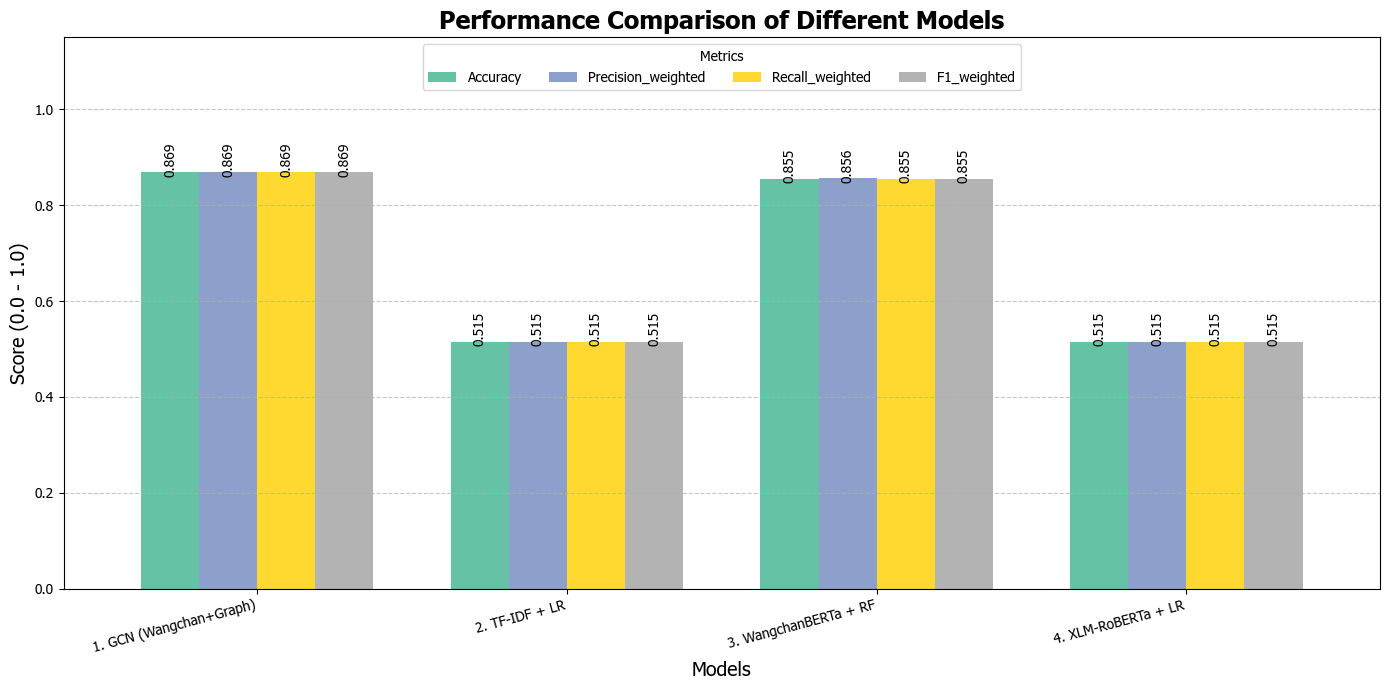

In [50]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from pythainlp.tokenize import word_tokenize
# ====================================================================
# PART 3 — Baseline Models Comparison
# ====================================================================
print("\n" + "="*80)
print("PART 3: BASELINE MODELS COMPARISON")
print("="*80)

texts_balanced = df.iloc[idx_balanced]['หัวข้อข่าว'].astype(str).tolist()
y_train_base   = y_balanced[idx_train]
y_test_base    = y_balanced[idx_test]

# ✅ สร้าง test_texts ที่นี่ครั้งเดียว → ใช้ใน PART 5-8
test_texts  = [texts_balanced[i] for i in idx_test]
train_texts = [texts_balanced[i] for i in idx_train]

results_comparison = {}
results_comparison['1. GCN (Wangchan+Graph)'] = results_gcn

# --- Baseline 1: TF-IDF + LR ---
print("\n🔄 Baseline 1: TF-IDF + Logistic Regression...")

def thai_tokenizer(text):
    return word_tokenize(text, engine='newmm', keep_whitespace=False)

tfidf         = TfidfVectorizer(tokenizer=thai_tokenizer, max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf  = tfidf.transform(test_texts)

clf_tfidf    = LogisticRegression(max_iter=1000, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train_base)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

results_comparison['2. TF-IDF + LR'] = {
    "Accuracy":           accuracy_score(y_test_base, y_pred_tfidf),
    "Precision_weighted": precision_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
    "Recall_weighted":    recall_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
    "F1_weighted":        f1_score(y_test_base, y_pred_tfidf, average='weighted', zero_division=0),
}
print("✅ Done")

# --- Baseline 2: WangchanBERTa + RF ---
print("\n🔄 Baseline 2: WangchanBERTa + Random Forest...")

X_train_wcb   = x_balanced[idx_train]
X_test_wcb    = x_balanced[idx_test]
clf_rf        = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(X_train_wcb, y_train_base)
y_pred_wcb_rf = clf_rf.predict(X_test_wcb)

results_comparison['3. WangchanBERTa + RF'] = {
    "Accuracy":           accuracy_score(y_test_base, y_pred_wcb_rf),
    "Precision_weighted": precision_score(y_test_base, y_pred_wcb_rf, average='weighted', zero_division=0),
    "Recall_weighted":    recall_score(y_test_base, y_pred_wcb_rf, average='weighted', zero_division=0),
    "F1_weighted":        f1_score(y_test_base, y_pred_wcb_rf, average='weighted', zero_division=0),
}
print("✅ Done")

# --- Baseline 3: XLM-RoBERTa + LR ---
print("\n🔄 Baseline 3: XLM-RoBERTa + Logistic Regression...")

model_xlm_name = "xlm-roberta-base"
tokenizer_xlm  = AutoTokenizer.from_pretrained(model_xlm_name)
model_xlm      = AutoModel.from_pretrained(model_xlm_name).to(device).eval()

xlm_emb      = get_bert_embeddings_batch(
    texts_balanced, tokenizer=tokenizer_xlm, model=model_xlm,
    device=device, max_length=256, batch_size=32, use_mean_pool=True
)
xlm_emb_norm = normalize(xlm_emb, axis=1, norm='l2')

X_train_xlm  = xlm_emb_norm[idx_train]
X_test_xlm   = xlm_emb_norm[idx_test]

clf_xlm      = LogisticRegression(max_iter=1000, random_state=42)
clf_xlm.fit(X_train_xlm, y_train_base)
y_pred_xlm   = clf_xlm.predict(X_test_xlm)

results_comparison['4. XLM-RoBERTa + LR'] = {
    "Accuracy":           accuracy_score(y_test_base, y_pred_xlm),
    "Precision_weighted": precision_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
    "Recall_weighted":    recall_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
    "F1_weighted":        f1_score(y_test_base, y_pred_xlm, average='weighted', zero_division=0),
}
print("✅ Baseline 3 Done!")

# --- Comparison Table & Chart ---
print("\n" + "="*80)
print("📊 MODEL COMPARISON RESULTS")
print("="*80)

df_results = pd.DataFrame(results_comparison).T
df_results = df_results[['Accuracy','Precision_weighted','Recall_weighted','F1_weighted']]
print(df_results.round(4))

fig, ax = plt.subplots(figsize=(14, 7))
df_results.plot(kind='bar', ax=ax, colormap='Set2', width=0.75)
ax.set_title('Performance Comparison of Different Models', fontsize=18, fontweight='bold')
ax.set_xlabel('Models', fontsize=14)
ax.set_ylabel('Score (0.0 - 1.0)', fontsize=14)
ax.set_ylim(0, 1.15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(title='Metrics', loc='upper center', ncol=4)
ax.grid(axis='y', linestyle='--', alpha=0.7)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points', fontsize=10, rotation=90)
plt.tight_layout()
plt.show()



PART 4: CONFUSION MATRICES


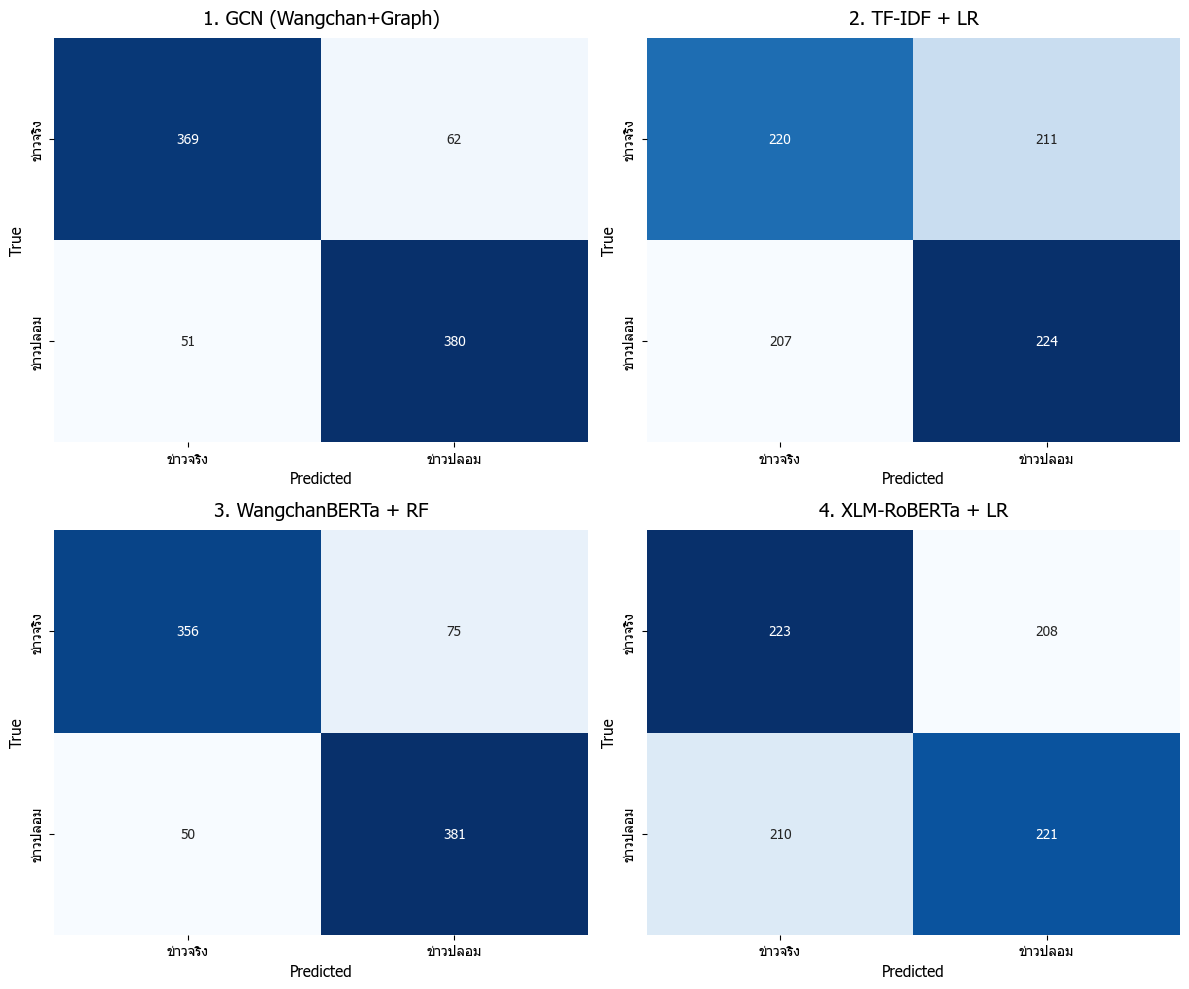

In [51]:
# ====================================================================
# PART 4 — Confusion Matrices (All Models)
# ====================================================================
print("\n" + "="*80)
print("PART 4: CONFUSION MATRICES")
print("="*80)

class_names       = [id2label[0], id2label[1]]
model_predictions = [
    ("1. GCN (Wangchan+Graph)", y_true_gcn,  y_pred_gcn),
    ("2. TF-IDF + LR",          y_test_base, y_pred_tfidf),
    ("3. WangchanBERTa + RF",   y_test_base, y_pred_wcb_rf),
    ("4. XLM-RoBERTa + LR",    y_test_base, y_pred_xlm),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes      = axes.flatten()
for i, (mname, yt, yp) in enumerate(model_predictions):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[i].set_title(mname, fontsize=14, pad=10)
    axes[i].set_xlabel('Predicted', fontsize=11)
    axes[i].set_ylabel('True', fontsize=11)
plt.tight_layout()
plt.show()

In [52]:
# ====================================================================
# PART 5 — Error Analysis: GCN
# ====================================================================
print("\n" + "="*80)
print("PART 5: GCN ERROR ANALYSIS")
print("="*80)

# ✅ ตรวจสอบขนาดให้ตรงกัน
assert len(test_texts) == len(y_true_gcn), (
    f"Size mismatch: test_texts={len(test_texts)}, y_true_gcn={len(y_true_gcn)}"
)

misclassified_samples = []
for i in range(len(y_true_gcn)):
    tl = y_true_gcn[i]; pl = y_pred_gcn[i]
    if tl != pl:
        misclassified_samples.append({
            'text':            test_texts[i],
            'true_label_text': id2label[tl],
            'pred_label_text': id2label[pl],
            'error_type':      ("False Positive (หลงผิดคิดว่าปลอม)"
                               if pl == 1 else
                               "False Negative (โดนหลอกคิดว่าจริง)")
        })

print(f"พบข่าวที่ทายผิด: {len(misclassified_samples)} / {len(y_true_gcn)}")
for idx, item in enumerate(misclassified_samples[:20]):
    print(f"\n[{idx+1}] ❌ {item['error_type']}")
    print(f"เนื้อหา : {item['text']}")
    print(f"จริง: {item['true_label_text']} | ทำนาย: {item['pred_label_text']}")
    print("-" * 70)



PART 5: GCN ERROR ANALYSIS
พบข่าวที่ทายผิด: 113 / 862

[1] ❌ False Negative (โดนหลอกคิดว่าจริง)
เนื้อหา :  กระทรวงเเรงงานรับสมัครสอบงานโรงงาน โควตา 2,285 คน ค่าแรง 52,000 บาท ไม่รวมโอที
จริง: ข่าวปลอม | ทำนาย: ข่าวจริง
----------------------------------------------------------------------

[2] ❌ False Positive (หลงผิดคิดว่าปลอม)
เนื้อหา :  ขายหมูที่แผงตนเอง ต้องนำหมูของซีพีมาขาย 50% ไม่อย่างนั้นจะผิดกฎหมาย
จริง: ข่าวจริง | ทำนาย: ข่าวปลอม
----------------------------------------------------------------------

[3] ❌ False Negative (โดนหลอกคิดว่าจริง)
เนื้อหา : กระทรวงสาธารณสุข ยืนยัน เบกกิ้งโซดา ช่วยให้สายตากลับมามองเห็นชัดใน 5 วัน
จริง: ข่าวปลอม | ทำนาย: ข่าวจริง
----------------------------------------------------------------------

[4] ❌ False Negative (โดนหลอกคิดว่าจริง)
เนื้อหา :  ธ. กรุงไทย ปล่อยสินเชื่อกรุงไทยใจป๋า อนุมัติสูงสุด 5 ล้านบาท ไม่ต้องมีหลักประกันผ่านเพจ “บอกต่อ”
จริง: ข่าวปลอม | ทำนาย: ข่าวจริง
----------------------------------------------------------------------

[

In [53]:
# ====================================================================
# PART 6 — Keyword Analysis for Misclassified News
# ====================================================================
print("\n" + "="*80)
print("PART 6: KEYWORD ANALYSIS")
print("="*80)

stopwords_set = set(thai_stopwords())
custom_sw     = {' ','\n','(',')','\"',"'",'!','?','-','"','"',':','/','ๆ',
                 'ได้','ที่','ใน','การ','และ','เป็น','มี','ให้','ของ','จะ','ว่า'}
all_stopwords = stopwords_set.union(custom_sw)

def get_top_keywords(news_list, top_n=15):
    all_words = []
    for item in news_list:
        words = word_tokenize(str(item['text']), engine='newmm', keep_whitespace=False)
        all_words.extend([w for w in words if w not in all_stopwords and len(w) > 1])
    return




PART 6: KEYWORD ANALYSIS


In [54]:
# ====================================================================
# PART 5 — Error Analysis: ดึงข่าวที่โมเดล GCN ทายผิดพลาด
# ====================================================================
print("\n" + "="*80)
print("🚨 ERROR ANALYSIS: ข่าวที่โมเดล GCN ทายผิดพลาด (Test Set)")
print("="*80)

# 1. ดึง index ของข้อมูลที่เป็น Test set (อิงจาก mask ที่เราสร้างไว้)
test_indices = np.where(data_st.test_mask.cpu().numpy())[0]

# 2. ดึงข้อความข่าวเฉพาะในชุด Test set 
# (texts_balanced ถูกสร้างไว้ตอนรันโมเดล Baseline)
texts_test = [texts_balanced[i] for i in test_indices]

# 3. รวบรวมข่าวที่ทายผิด
misclassified_samples = []
for i in range(len(y_true_gcn)):
    true_label = y_true_gcn[i]
    pred_label = y_pred_gcn[i]
    
    # ถ้าค่าจริง ไม่ตรงกับ ค่าที่ทำนาย -> แปลว่าทายผิด
    if true_label != pred_label:
        error_type = "False Positive (หลงผิดคิดว่าปลอม)" if pred_label == 1 else "False Negative (โดนหลอกคิดว่าจริง)"
        
        misclassified_samples.append({
            'text': texts_test[i],
            'true_label_text': id2label[true_label],
            'pred_label_text': id2label[pred_label],
            'error_type': error_type
        })

# 4. แสดงผลลัพธ์ (จำกัดที่ 20 ข่าว)
num_to_show = 20
total_errors = len(misclassified_samples)

print(f"พบข่าวที่ทายผิดทั้งหมด {total_errors} ข่าว (จาก {len(y_true_gcn)} ข่าวในชุดทดสอบ)")
print(f"กำลังแสดงตัวอย่าง {min(num_to_show, total_errors)} ข่าวแรก:\n")

for idx, item in enumerate(misclassified_samples[:num_to_show]):
    print(f"[{idx+1}] ❌ {item['error_type']}")
    print(f"เนื้อหาข่าว : {item['text']}")
    print(f"ค่าจริง (True) : {item['true_label_text']} | ทำนาย (Pred) : {item['pred_label_text']}")
    print("-" * 70)

# (Optional) หากต้องการบันทึกข่าวที่ทายผิดทั้งหมดลง CSV เพื่อเอาไปวิเคราะห์ต่อใน Excel
# df_errors = pd.DataFrame(misclassified_samples)
# df_errors.to_csv('misclassified_news_gcn.csv', index=False, encoding='utf-8-sig')
# print("\n✅ บันทึกข่าวที่ทายผิดทั้งหมดลงไฟล์ 'misclassified_news_gcn.csv' เรียบร้อยแล้ว")


🚨 ERROR ANALYSIS: ข่าวที่โมเดล GCN ทายผิดพลาด (Test Set)
พบข่าวที่ทายผิดทั้งหมด 113 ข่าว (จาก 862 ข่าวในชุดทดสอบ)
กำลังแสดงตัวอย่าง 20 ข่าวแรก:

[1] ❌ False Negative (โดนหลอกคิดว่าจริง)
เนื้อหาข่าว :  ธนาคารพัฒนาวิสาหกิจขนาดกลางและขนาดย่อมแห่งประเทศไทยเปิดเว็บไซต์ใหม่ https://sme-bank.makeweb.co/
ค่าจริง (True) : ข่าวปลอม | ทำนาย (Pred) : ข่าวจริง
----------------------------------------------------------------------
[2] ❌ False Positive (หลงผิดคิดว่าปลอม)
เนื้อหาข่าว :  ผู้ประกอบการที่ใช้ตราฮาลาลบนสินค้า ไม่ต้องเสียภาษี
ค่าจริง (True) : ข่าวจริง | ทำนาย (Pred) : ข่าวปลอม
----------------------------------------------------------------------
[3] ❌ False Negative (โดนหลอกคิดว่าจริง)
เนื้อหาข่าว : ทหารไทยฐานภูมะเขือขาดเสบียง กินแต่มาม่า-ปลากระป๋อง น้ำดื่มได้แค่วันละ 3 ขวด
ค่าจริง (True) : ข่าวปลอม | ทำนาย (Pred) : ข่าวจริง
----------------------------------------------------------------------
[4] ❌ False Negative (โดนหลอกคิดว่าจริง)
เนื้อหาข่าว :  ลอตเตอรี่ที่มีสัญลักษณ์ผีน้อย และกบไชโย


📊 KEYWORD ANALYSIS: คำศัพท์ที่มักทำให้โมเดลทายผิด
📌 Top 15 คำในข่าวที่โมเดล 'หลงผิดคิดว่าปลอม' (False Positive / ความจริงคือข่าวจริง):
   - บาท: 12 ครั้ง
   - เพจ: 7 ครั้ง
   - ทำ: 6 ครั้ง
   - ไทย: 5 ครั้ง
   - ออมสิน: 5 ครั้ง
   - ดื่ม: 4 ครั้ง
   - 19: 4 ครั้ง
   - เตรียม: 3 ครั้ง
   - รักษา: 3 ครั้ง
   - โรคมะเร็ง: 3 ครั้ง
   - จ่าย: 3 ครั้ง
   - หมื่น: 3 ครั้ง
   - สุขภาพ: 3 ครั้ง
   - 15: 3 ครั้ง
   - เจ้าหน้าที่: 3 ครั้ง

📌 Top 15 คำในข่าวที่โมเดล 'โดนหลอกคิดว่าจริง' (False Negative / ความจริงคือข่าวปลอม):
   - บาท: 13 ครั้ง
   - เพจ: 8 ครั้ง
   - ไทย: 6 ครั้ง
   - ปี: 5 ครั้ง
   - ปล่อย: 5 ครั้ง
   - สินเชื่อ: 5 ครั้ง
   - ธนาคาร: 4 ครั้ง
   - ลงทุน: 4 ครั้ง
   - กู้: 4 ครั้ง
   - ล้าน: 4 ครั้ง
   - หุ้น: 4 ครั้ง
   - เว็บไซต์: 3 ครั้ง
   - ก.ล.ต.: 3 ครั้ง
   - วงเงิน: 3 ครั้ง
   - สิทธิ: 3 ครั้ง


C:\Users\tt_pe\AppData\Local\Temp\ipykernel_24592\2299393337.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_fp), y=list(words_fp), ax=axes[0], palette='Reds_r')
C:\Users\tt_pe\AppData\Local\Temp\ipykernel_24592\2299393337.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_fn), y=list(words_fn), ax=axes[1], palette='Oranges_r')


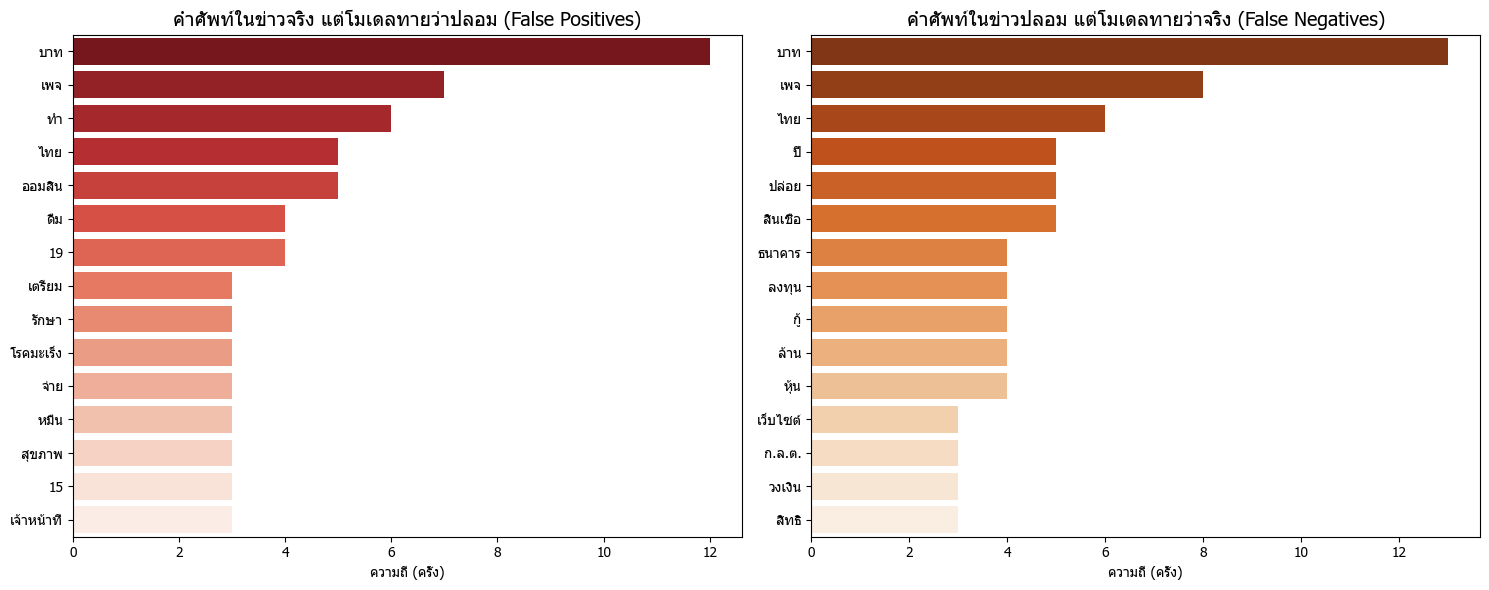


✅ บันทึกกราฟคำศัพท์ที่ผิดพลาดลงไฟล์ 'graph_error_keywords.png' เรียบร้อยแล้ว


In [55]:
# ====================================================================
# PART 6 — Keyword Analysis for Misclassified News (สถิติคำที่ทำโมเดลสับสน)
# ====================================================================
from pythainlp.corpus import thai_stopwords
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("📊 KEYWORD ANALYSIS: คำศัพท์ที่มักทำให้โมเดลทายผิด")
print("="*80)

# 1. โหลด Stopwords ภาษาไทย และเพิ่มคำที่ไม่อยากให้นับ (Custom Stopwords)
stopwords = set(thai_stopwords())
custom_stopwords = {' ', '\n', '(', ')', '"', "'", '!', '?', '-', '”', '“', ':', '/', 'ๆ', 
                    'ได้', 'ที่', 'ใน', 'การ', 'และ', 'เป็น', 'มี', 'ให้', 'ของ', 'จะ', 'ว่า'}
all_stopwords = stopwords.union(custom_stopwords)

# ฟังก์ชันสำหรับสกัดและนับคำศัพท์จาก List ของข่าว
def get_top_keywords(news_list, top_n=15):
    all_words = []
    for item in news_list:
        text = str(item['text'])
        # ตัดคำด้วย newmm
        words = word_tokenize(text, engine='newmm', keep_whitespace=False)
        # กรองคำที่เป็น stopword และคำที่สั้นเกินไป (ยาว < 2)
        filtered_words = [w for w in words if w not in all_stopwords and len(w) > 1]
        all_words.extend(filtered_words)
    
    # นับความถี่และคืนค่าคำที่เจอบ่อยสุด
    return Counter(all_words).most_common(top_n)

# 2. แยกกลุ่มข่าวที่ทายผิด (จากตัวแปร misclassified_samples ใน Part 5)
fp_news = [item for item in misclassified_samples if "False Positive" in item['error_type']]
fn_news = [item for item in misclassified_samples if "False Negative" in item['error_type']]

# ดึง Top 15 Keywords
top_fp_words = get_top_keywords(fp_news, top_n=15)
top_fn_words = get_top_keywords(fn_news, top_n=15)

# 3. พิมพ์ผลลัพธ์ออกทางหน้าจอ
print(f"📌 Top 15 คำในข่าวที่โมเดล 'หลงผิดคิดว่าปลอม' (False Positive / ความจริงคือข่าวจริง):")
for word, count in top_fp_words:
    print(f"   - {word}: {count} ครั้ง")

print(f"\n📌 Top 15 คำในข่าวที่โมเดล 'โดนหลอกคิดว่าจริง' (False Negative / ความจริงคือข่าวปลอม):")
for word, count in top_fn_words:
    print(f"   - {word}: {count} ครั้ง")

# 4. พลอตกราฟเปรียบเทียบ (Bar Chart)
if len(top_fp_words) > 0 and len(top_fn_words) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # พลอตฝั่ง False Positive (สีแดง)
    words_fp, counts_fp = zip(*top_fp_words)
    sns.barplot(x=list(counts_fp), y=list(words_fp), ax=axes[0], palette='Reds_r')
    axes[0].set_title('คำศัพท์ในข่าวจริง แต่โมเดลทายว่าปลอม (False Positives)', fontsize=14)
    axes[0].set_xlabel('ความถี่ (ครั้ง)')
    
    # พลอตฝั่ง False Negative (สีส้ม)
    words_fn, counts_fn = zip(*top_fn_words)
    sns.barplot(x=list(counts_fn), y=list(words_fn), ax=axes[1], palette='Oranges_r')
    axes[1].set_title('คำศัพท์ในข่าวปลอม แต่โมเดลทายว่าจริง (False Negatives)', fontsize=14)
    axes[1].set_xlabel('ความถี่ (ครั้ง)')
    
    plt.tight_layout()
    #plt.savefig('graph_error_keywords.png', dpi=300)
    plt.show()
    print("\n✅ บันทึกกราฟคำศัพท์ที่ผิดพลาดลงไฟล์ 'graph_error_keywords.png' เรียบร้อยแล้ว")
else:
    print("\n⚠️ ไม่พบข้อมูลคำศัพท์เพียงพอที่จะพลอตกราฟ (โมเดลอาจจะทายถูกเกือบหมด!)")

In [56]:
# ====================================================================
# PART 7 — Cross-Model Error Analysis (วิเคราะห์จุดอ่อนของทั้ง 4 โมเดล)
# ====================================================================
import pandas as pd
import numpy as np

print("\n" + "="*80)
print("🕵️‍♂️ CROSS-MODEL ERROR ANALYSIS: ค้นหา 'ข่าวปราบเซียน' ที่หลอกได้ทุกโมเดล")
print("="*80)

# 1. สร้าง DataFrame รวบรวมผลทายของทุกโมเดลใน Test Set
# อิงจากตัวแปรที่เรามีในโค้ดก่อนหน้า
df_errors_all = pd.DataFrame({
    'text': test_texts,           # ใช้ test_texts ที่ดึงไว้จาก PART 3
    'true_label': y_test_base,
    'pred_gcn': y_pred_gcn,
    'pred_wcb': y_pred_wcb_rf,    # ✅ แก้ชื่อตัวแปรตรงนี้เป็น y_pred_wcb_rf (Random Forest)
    'pred_xlm': y_pred_xlm,
    'pred_tfidf': y_pred_tfidf
})

# แปลง Label ตัวเลขเป็นข้อความให้ดูง่าย
df_errors_all['true_label_text'] = df_errors_all['true_label'].map({0: id2label[0], 1: id2label[1]})

# 2. เช็คว่าแต่ละโมเดลทายผิดหรือไม่ (True = ทายผิด, False = ทายถูก)
df_errors_all['gcn_wrong'] = df_errors_all['true_label'] != df_errors_all['pred_gcn']
df_errors_all['wcb_wrong'] = df_errors_all['true_label'] != df_errors_all['pred_wcb']
df_errors_all['xlm_wrong'] = df_errors_all['true_label'] != df_errors_all['pred_xlm']
df_errors_all['tfidf_wrong'] = df_errors_all['true_label'] != df_errors_all['pred_tfidf']

# นับจำนวนโมเดลที่ทายผิดในข่าวนั้นๆ (0 ถึง 4)
df_errors_all['num_models_wrong'] = (
    df_errors_all['gcn_wrong'].astype(int) + 
    df_errors_all['wcb_wrong'].astype(int) + 
    df_errors_all['xlm_wrong'].astype(int) + 
    df_errors_all['tfidf_wrong'].astype(int)
)

# แยกประเภท Error
def get_error_type(true_label):
    return "False Positive (จริงแต่ทายปลอม)" if true_label == 0 else "False Negative (ปลอมแต่ทายจริง)"

df_errors_all['error_type'] = df_errors_all['true_label'].apply(get_error_type)

# ---------------------------------------------------------
# สรุปสถิติ
# ---------------------------------------------------------
total_test = len(df_errors_all)
all_wrong_df = df_errors_all[df_errors_all['num_models_wrong'] == 4]
gcn_only_correct_df = df_errors_all[(df_errors_all['num_models_wrong'] == 3) & (~df_errors_all['gcn_wrong'])]

print(f"📊 สรุปจากข้อมูลทดสอบทั้งหมด {total_test} ข่าว:")
print(f"  - ข่าวที่ทายผิดทั้ง 4 โมเดล (ข่าวปราบเซียน): {len(all_wrong_df)} ข่าว")
print(f"  - ข่าวที่ GCN ทายถูกตัวเดียว (โมเดลอื่นโดนหลอกหมด): {len(gcn_only_correct_df)} ข่าว")

# ---------------------------------------------------------
# แสดงผล "ข่าวปราบเซียน" (ทายผิดทั้ง 4 โมเดล)
# ---------------------------------------------------------
print("\n🚨 ตัวอย่างข่าวที่หลอกได้ทุกโมเดล (Hard Examples):")
show_n = min(10, len(all_wrong_df))
for idx, row in all_wrong_df.head(show_n).iterrows():
    print(f"\n[{idx}] ❌ {row['error_type']}")
    print(f"เนื้อหา : {row['text']}")
    print(f"-> ความเป็นจริงคือ: {row['true_label_text']}")
    print("-" * 60)

# # 3. บันทึกผลลัพธ์ทั้งหมดลง CSV เพื่อนำไปวิเคราะห์ด้วยตา (Qualitative Analysis)
# csv_filename = "compare_all_models_errors.csv"
# # จัดเรียงคอลัมน์ให้ดูง่ายขึ้น
# cols_to_save = ['text', 'true_label_text', 'error_type', 'num_models_wrong', 
#                 'pred_gcn', 'pred_wcb', 'pred_xlm', 'pred_tfidf']
# df_errors_all[cols_to_save].sort_values(by='num_models_wrong', ascending=False).to_csv(csv_filename, index=False, encoding='utf-8-sig')

# print(f"\n✅ บันทึกข้อมูลเปรียบเทียบการทายผิดทั้งหมดลงไฟล์ '{csv_filename}' เรียบร้อยแล้ว (เปิดดูใน Excel ได้เลยครับ)")


🕵️‍♂️ CROSS-MODEL ERROR ANALYSIS: ค้นหา 'ข่าวปราบเซียน' ที่หลอกได้ทุกโมเดล
📊 สรุปจากข้อมูลทดสอบทั้งหมด 862 ข่าว:
  - ข่าวที่ทายผิดทั้ง 4 โมเดล (ข่าวปราบเซียน): 16 ข่าว
  - ข่าวที่ GCN ทายถูกตัวเดียว (โมเดลอื่นโดนหลอกหมด): 16 ข่าว

🚨 ตัวอย่างข่าวที่หลอกได้ทุกโมเดล (Hard Examples):

[3] ❌ False Negative (ปลอมแต่ทายจริง)
เนื้อหา :  ธนาคารกรุงไทยเปิดเพจเฟซบุ๊กชื่อ Hip Hop เพื่อรับเงินทุน
-> ความเป็นจริงคือ: ข่าวปลอม
------------------------------------------------------------

[23] ❌ False Negative (ปลอมแต่ทายจริง)
เนื้อหา : สำนักงานสลากฯ เปิดให้ขึ้นเงินรางวัลแบบ Drive Thru จริงหรือ?
-> ความเป็นจริงคือ: ข่าวปลอม
------------------------------------------------------------

[240] ❌ False Negative (ปลอมแต่ทายจริง)
เนื้อหา :  SMS ของธนาคารกรุงไทยขอสินเชื่อผ่านลิงก์
-> ความเป็นจริงคือ: ข่าวปลอม
------------------------------------------------------------

[263] ❌ False Negative (ปลอมแต่ทายจริง)
เนื้อหา : ดอกแคบ้าน กินแก้ไตรกลีเซอไรด์สูง ไขมันพอกตับ และช่วยแก้โรคเกาต์ 
-> ความเป็นจริงคือ: ข่าว

In [57]:
    # ====================================================================
    # PART 8 — Individual Model Error Analysis (แสดงข่าวที่ทายผิดรายโมเดล)
    # ====================================================================
    print("\n" + "="*80)
    print("🔍 INDIVIDUAL ERROR ANALYSIS: เจาะลึกข่าวที่ทายผิดของแต่ละโมเดล")
    print("="*80)

    # แมปชื่อให้ตรงกับด้านบน
    models_list = [
        ("1. GCN (Wangchan+Graph)", y_pred_gcn),
        ("2. TF-IDF + LR", y_pred_tfidf),
        ("3. WangchanBERTa + RF", y_pred_wcb_rf),
        ("4. XLM-RoBERTa + LR", y_pred_xlm)
    ]

    num_to_show = 3 

    for model_name, y_pred in models_list:
        fp_list = [] 
        fn_list = [] 
        
        for i in range(len(y_test_base)):
            true_lbl = y_test_base[i]
            pred_lbl = y_pred[i]
            
            if true_lbl != pred_lbl:
                error_data = {
                    'text': texts_test[i],
                    'true_label_text': id2label[true_lbl],
                    'pred_label_text': id2label[pred_lbl]
                }
                if pred_lbl == 1:
                    fp_list.append(error_data)
                else:
                    fn_list.append(error_data)
                    
        print(f"\n" + "-"*60)
        print(f"🤖 โมเดล: {model_name}")
        print(f"   ทายผิดทั้งหมด: {len(fp_list) + len(fn_list)} ข่าว (FP: {len(fp_list)}, FN: {len(fn_list)})")
        print("-" * 60)
        
        print(f"  🔻 ตัวอย่าง False Positives (ความจริงคือ '{id2label[0]}' แต่โมเดลทาย '{id2label[1]}'):")
        for idx, item in enumerate(fp_list[:num_to_show]):
            print(f"     [{idx+1}] ข้อความ: {item['text']}")
        if not fp_list:
            print("     (ไม่มีทายผิดในกลุ่มนี้ 🎉)")
            
        print(f"\n  🔺 ตัวอย่าง False Negatives (ความจริงคือ '{id2label[1]}' แต่โมเดลทาย '{id2label[0]}'):")
        for idx, item in enumerate(fn_list[:num_to_show]):
            print(f"     [{idx+1}] ข้อความ: {item['text']}")
        if not fn_list:
            print("     (ไม่มีทายผิดในกลุ่มนี้ 🎉)")
            
    print("\n" + "="*80)


🔍 INDIVIDUAL ERROR ANALYSIS: เจาะลึกข่าวที่ทายผิดของแต่ละโมเดล

------------------------------------------------------------
🤖 โมเดล: 1. GCN (Wangchan+Graph)
   ทายผิดทั้งหมด: 447 ข่าว (FP: 229, FN: 218)
------------------------------------------------------------
  🔻 ตัวอย่าง False Positives (ความจริงคือ 'ข่าวจริง' แต่โมเดลทาย 'ข่าวปลอม'):
     [1] ข้อความ: การรื้อถอนสิ่งปลูกสร้างของประชาชนกัมพูชาที่รุกล้ำเขตไทย เป็นไปตามหลักกฎหมาย
     [2] ข้อความ:  ระบบเว็บไซต์กรมการปกครองยังคงใช้ตรวจสอบข้อมูลการฉีดวัคซีนได้
     [3] ข้อความ: รังสียูวี (UV) หนึ่งในสาเหตุที่ทำให้เกิดโรคมะเร็งผิวหนัง จริงหรือ?

  🔺 ตัวอย่าง False Negatives (ความจริงคือ 'ข่าวปลอม' แต่โมเดลทาย 'ข่าวจริง'):
     [1] ข้อความ: ธอส. ออกมาตรการช่วยเหลือประชาชนชายแดนไทย–กัมพูชา
     [2] ข้อความ: รอรถเมล์นานสามารถร้องเรียนได้ที่เพจ ขสมก. พร้อมบวก จริงหรือ?
     [3] ข้อความ:  เพจ Dododo ชวนกู้เงินออนไลน์โครงการสินเชื่อสู้ไปด้วยกัน

------------------------------------------------------------
🤖 โมเดล: 2. TF-IDF + LR
   ทายผิดทั